## 1. Introduction

This analysis explores blood glucose levels in the Pima Indians Diabetes dataset, examining how glucose distribution differs between patients with and without diabetes, and whether any values in the dataset appear to be statistical outliers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

df = pd.read_csv('../data/diabetes.csv')
print(df.shape)
print(df.describe())

(768, 9)
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000         

In [2]:
glucose = df['Glucose'].tolist()

mean_g = sum(glucose) / len(glucose)

sorted_g = sorted(glucose)
n = len(sorted_g)
if n % 2 == 1:
    median_g = sorted_g[n // 2]
else:
    median_g = (sorted_g[n // 2 - 1] + sorted_g[n // 2]) / 2

variance_g = sum((x - mean_g) ** 2 for x in glucose) / len(glucose)
sd_g = math.sqrt(variance_g)

lower_bound = mean_g - 2 * sd_g
upper_bound = mean_g + 2 * sd_g
outliers = [x for x in glucose if x < lower_bound or x > upper_bound]

print(f"Mean glucose: {mean_g:.1f}")
print(f"Median glucose: {median_g}")
print(f"Standard deviation: {sd_g:.1f}")
print(f"Outlier boundaries: {lower_bound:.1f} to {upper_bound:.1f}")
print(f"Outliers found: {outliers}")
print(f"Outlier count: {len(outliers)}")

Mean glucose: 120.9
Median glucose: 117.0
Standard deviation: 32.0
Outlier boundaries: 57.0 to 184.8
Outliers found: [197, 189, 196, 187, 44, 0, 188, 0, 194, 196, 197, 193, 191, 194, 0, 0, 196, 189, 193, 197, 189, 194, 195, 0, 186, 187, 189, 198, 197, 188, 199, 195, 56, 187, 187, 190]
Outlier count: 36


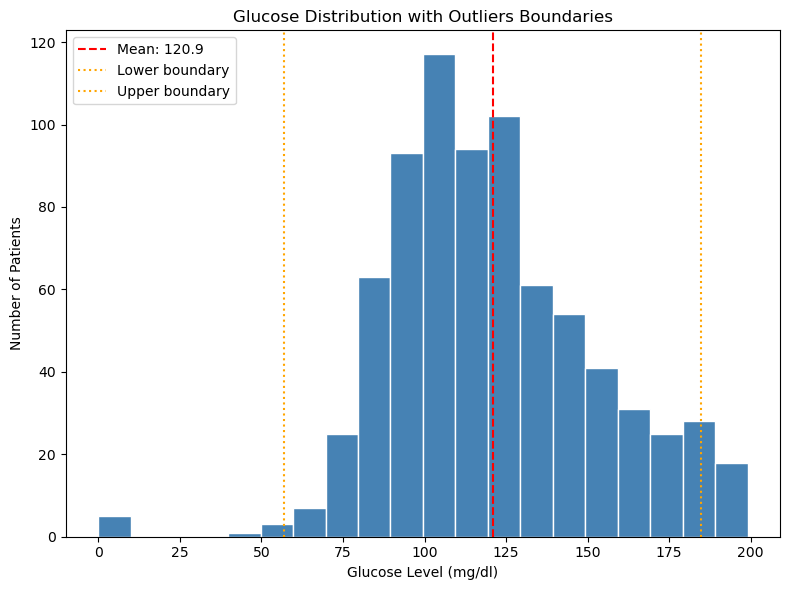

In [7]:
plt.figure(figsize=(8,6))
plt.hist(glucose, bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_g, color='red', linestyle='--', 
            label=f"Mean: {mean_g:.1f}")
plt.axvline(lower_bound, color='orange', linestyle=':',
            label='Lower boundary')
plt.axvline(upper_bound, color='orange', linestyle=':',
            label='Upper boundary')
plt.xlabel('Glucose Level (mg/dl)')
plt.ylabel('Number of Patients')
plt.title('Glucose Distribution with Outliers Boundaries')
plt.legend()
plt.tight_layout()
plt.savefig('../data/day19_glucose_outliers.png', dpi=150)
plt.show()

## 5. Interpretation

The mean glucose level across 768 patients is 120.9mg/dL, with a standard deviation of 32.0mg/dL. The median 117.0 is [lower than the mean, suggesting the distribution is positively skewed.

Using the 2-SD rule from Week 1, 36 values were flagged as outliers, falling outside the range of 57.0 to 184.8. Looking at these specific values, some had the impossible zero values(missing values) while there were other genuinely plausible high values.

If I were reviewing this data clinically, I would investigate the zero values as a data quality issue and I will investigate the really high values as they are danger signals.

This exercise confirms that my manual calculations from Week 1 and Pandas's built-in functions produce matching 
results.